# Movie Sentiment Classification using Decision Tree

## Q1) Load the IMDB dataset and display basic information
**Answer:** Load `imdb_labelled.txt`, show first 10 records, shape, columns, missing values, duplicates, and sentiment counts.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------
# Load Dataset
# ---------------------------

df = pd.read_csv("imdb_labelled.txt", sep=" ", header=None)
df.columns = ["review", "sentiment"]

print("First 10 records:")
print(df.head(10))

print("Dataset shape:", df.shape)

print("Column information:")
print(df.info())

# ---------------------------
# Missing and Duplicate Check
# ---------------------------

print("Missing values:")
print(df.isnull().sum())

print("Duplicate reviews:", df.duplicated().sum())

# ---------------------------
# Sentiment Distribution
# ---------------------------

print("Sentiment count:")
print(df["sentiment"].value_counts())

sns.countplot(x="sentiment", data=df)
plt.title("Positive vs Negative Reviews")
plt.xlabel("Sentiment (1 = Positive, 0 = Negative)")
plt.ylabel("Count")
plt.show()

ParserError: Error tokenizing data. C error: Expected 15 fields in line 2, saw 21


In [ ]:
import sklearn.tree
dir(sklearn.tree)

['BaseDecisionTree',
 'DecisionTreeClassifier',
 'DecisionTreeRegressor',
 'ExtraTreeClassifier',
 'ExtraTreeRegressor',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_classes',
 '_criterion',
 '_export',
 '_partitioner',
 '_reingold_tilford',
 '_splitter',
 '_tree',
 '_utils',
 'export_graphviz',
 'export_text',
 'plot_tree']

## Q2) How to preprocess text and convert to numeric features?
**Answer:** Use TF-IDF vectorizer with stop-word removal.

In [ ]:
# ---------------------------
# Text Preprocessing
# ---------------------------

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["review"])
y = df["sentiment"]

In [ ]:
help(TfidfVectorizer)

Help on class TfidfVectorizer in module sklearn.feature_extraction.text:

class TfidfVectorizer(CountVectorizer)
 |  TfidfVectorizer(
 |      *,
 |      input='content',
 |      encoding='utf-8',
 |      decode_error='strict',
 |      strip_accents=None,
 |      lowercase=True,
 |      preprocessor=None,
 |      tokenizer=None,
 |      analyzer='word',
 |      stop_words=None,
 |      token_pattern='(?u)\\b\\w\\w+\\b',
 |      ngram_range=(1, 1),
 |      max_df=1.0,
 |      min_df=1,
 |      max_features=None,
 |      vocabulary=None,
 |      binary=False,
 |      dtype=<class 'numpy.float64'>,
 |      norm='l2',
 |      use_idf=True,
 |      smooth_idf=True,
 |      sublinear_tf=False
 |  )
 |
 |  Convert a collection of raw documents to a matrix of TF-IDF features.
 |
 |  Equivalent to :class:`CountVectorizer` followed by
 |  :class:`TfidfTransformer`.
 |
 |  Read more in the :ref:`User Guide <tfidf>`.
 |
 |  Parameters
 |  ----------
 |  input : {'filename', 'file', 'content'}, defa

## Q3) How to split data and train a Decision Tree model?
**Answer:** Split into training and testing sets (80:20) and train Decision Tree with Gini index.

In [ ]:
# ---------------------------
# Train Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Train Decision Tree
# ---------------------------

model = DecisionTreeClassifier(criterion="gini", max_depth=5)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(
 |      *,
 |      criterion='gini',
 |      splitter='best',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features=None,
 |      random_state=None,
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      monotonic_cst=None
 |  )
 |
 |  A decision tree classifier.
 |
 |  Read more in the :ref:`User Guide <tree>`.
 |
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |
 |  splitter : {"best",

## Q4) Evaluate the model (Accuracy, Precision, Recall, F1, Confusion Matrix)
**Answer:** Predict test labels and compute all metrics.

In [34]:
# ---------------------------
# Predictions
# ---------------------------

pred = model.predict(X_test)

# ---------------------------
# Evaluation
# ---------------------------

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))

cm = confusion_matrix(y_test, pred)

print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_test, pred))

Accuracy: 0.6066666666666667
Precision: 0.5572519083969466
Recall: 0.9864864864864865
F1 Score: 0.7121951219512195
Confusion Matrix:
[[18 58]
 [ 1 73]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.24      0.38        76
           1       0.56      0.99      0.71        74

    accuracy                           0.61       150
   macro avg       0.75      0.61      0.55       150
weighted avg       0.75      0.61      0.54       150



## Q5) Visualize confusion matrix and decision tree
**Answer:** Use heatmap for confusion matrix and plot top levels of decision tree.

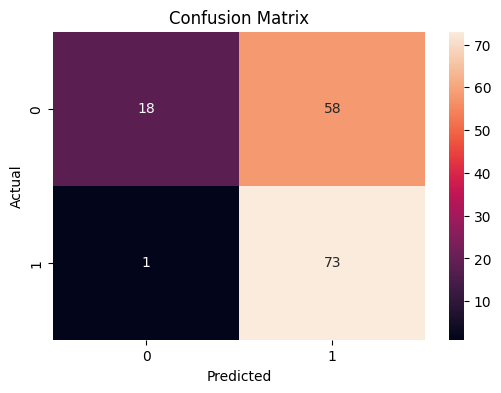

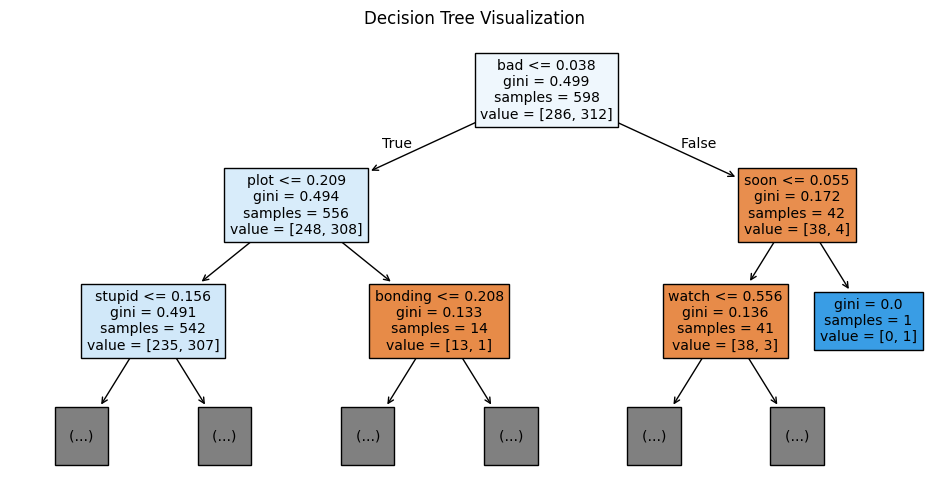

In [36]:
# ---------------------------
# Confusion Matrix Heatmap
# ---------------------------

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------
# Decision Tree Visualization
# ---------------------------

plt.figure(figsize=(12,6))
plot_tree(model, filled=True, max_depth=2, feature_names=vectorizer.get_feature_names_out())
plt.title("Decision Tree Visualization")
plt.show()

In [37]:
help(plot_tree)

Help on function plot_tree in module sklearn.tree._export:

plot_tree(
    decision_tree,
    *,
    max_depth=None,
    feature_names=None,
    class_names=None,
    label='all',
    filled=False,
    impurity=True,
    node_ids=False,
    proportion=False,
    rounded=False,
    precision=3,
    ax=None,
    fontsize=None
)
    Plot a decision tree.

    The sample counts that are shown are weighted with any sample_weights that
    might be present.

    The visualization is fit automatically to the size of the axis.
    Use the ``figsize`` or ``dpi`` arguments of ``plt.figure``  to control
    the size of the rendering.

    Read more in the :ref:`User Guide <tree>`.

    .. versionadded:: 0.21

    Parameters
    ----------
    decision_tree : decision tree regressor or classifier
        The decision tree to be plotted.

    max_depth : int, default=None
        The maximum depth of the representation. If None, the tree is fully
        generated.

    feature_names : array-like o

## Q6) Analyze false predictions and model behavior
**Answer:**
- False Positive: predicted positive but actual negative.
- False Negative: predicted negative but actual positive.
- Deep trees can overfit; very shallow trees can underfit.

In [ ]:
# ---------------------------
# False Predictions
# ---------------------------

fp = cm[0][1]
fn = cm[1][0]

print("False Positives:", fp)
print("False Negatives:", fn)

print("Model Behaviour:")
print("Decision Trees can overfit if depth is very large.")
print("Limiting tree depth helps prevent overfitting.")
print("Small trees may underfit if they cannot capture text patterns.")

False Positives: 58
False Negatives: 1
Model Behaviour:
Decision Trees can overfit if depth is very large.
Limiting tree depth helps prevent overfitting.
Small trees may underfit if they cannot capture text patterns.
